# Gymnasium, entornos y agente común

<a href="https://colab.research.google.com/github/NaoKB/AyalaFilardi-RL/blob/main/Entornos_Complejos/01_gymnasium_y_agente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

El primer objetivo es comprobar que los entornos y agentes siguen una interfaz
comun. Asi, los algoritmos cambian, pero el bucle de interaccion y las metricas se
mantienen iguales.

In [11]:
from pathlib import Path
import subprocess
import sys

candidates = [
    Path.cwd(),
    Path.cwd() / "Entornos_Complejos",
    Path("/content/EML/Entornos_Complejos"),
]
ROOT = next((path.resolve() for path in candidates if (path / "src").is_dir()), None)
if ROOT is None:
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/NaoKB/EML.git", "/content/EML"],
        check=True,
    )
    ROOT = Path("/content/EML/Entornos_Complejos")
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
print(f"Proyecto: {ROOT}")

from src.artifacts import result_path

def result(name):
    return result_path(RESULTS, name)

Proyecto: C:\Users\Joaquín\Desktop\EML\Entornos_Complejos


In [12]:
try:
    import gymnasium
except ModuleNotFoundError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "gymnasium==1.2.2"],
        check=True,
    )

## Contrato de los dos entornos

In [13]:
from gymnasium.utils.env_checker import check_env
from src.environments import RiverCourierEnv, ThermalGliderEnv

river = RiverCourierEnv(render_mode="ansi")
glider = ThermalGliderEnv(render_mode="ansi")
check_env(river, skip_render_check=True)
check_env(glider, skip_render_check=True)

print("RiverCourier:", river.observation_space, river.action_space)
print(river.render())
print()
print("ThermalGlider:", glider.observation_space, glider.action_space)
print(glider.render())

RiverCourier: Discrete(441) Discrete(5)
. . . . . . G
. . . . . . .
. . . . . . .
~ F ~ ~ ~ ~ B
. . . . . . .
A . . . . . .
. . . . . . .

ThermalGlider: Box([ 0.   -0.08  0.    0.  ], [1.2  0.16 1.5  1.  ], (4,), float32) Discrete(4)
x=0.004 v=-0.013 temp=0.260 bateria=0.852


RiverCourier usa un estado discreto que codifica posicion, fase
de marea y dano. ThermalGlider conserva una observacion continua; discretizarla
demasiado mezcla situaciones que requieren acciones distintas.

## Un único bucle para cualquier agente

In [14]:
import numpy as np
from src.core import Agent, run_episode

class RandomAgent(Agent):
    name = "agente aleatorio"

    def __init__(self, n_actions, seed=2026):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)

    def act(self, observation, training=True):
        return int(self.rng.integers(self.n_actions))

for env in (RiverCourierEnv(max_steps=20), ThermalGliderEnv(max_steps=20)):
    record, _ = run_episode(
        env,
        RandomAgent(env.action_space.n),
        seed=2026,
        training=False,
    )
    print(type(env).__name__, record)

RiverCourierEnv EpisodeRecord(episode=0, return_value=-2.69, length=20, success=False, incident=0, violation=False)
ThermalGliderEnv EpisodeRecord(episode=0, return_value=0.4681217114997174, length=20, success=False, incident=0, violation=False)


## Indicadores complementarios

Faltan resultados tabulares base; se regenerara el estudio RiverCourier.


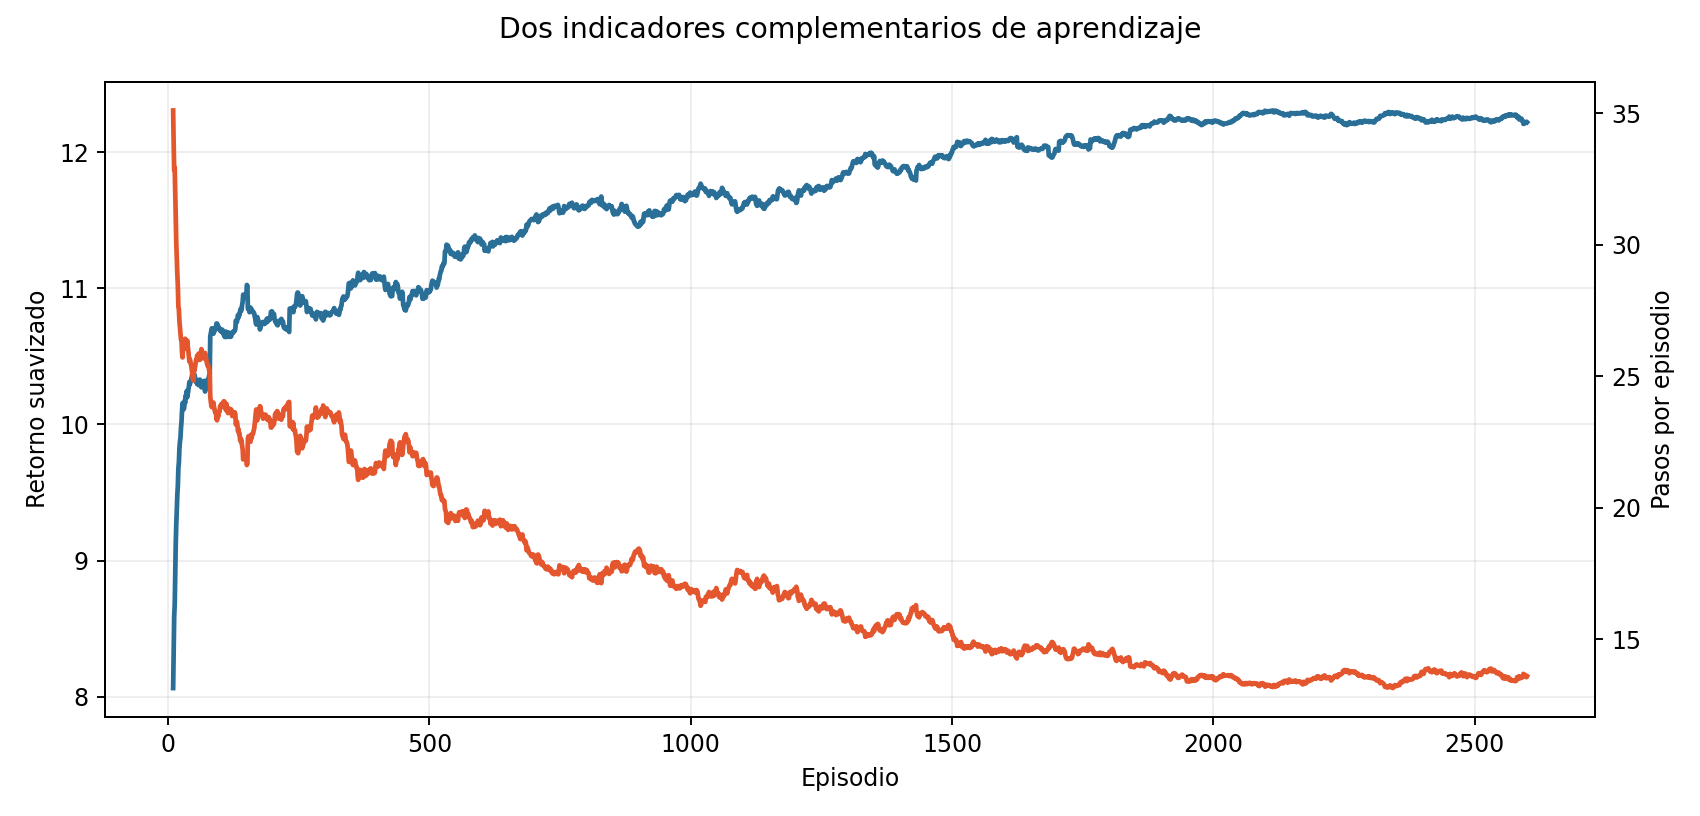

In [15]:
from IPython.display import Image, display

def show_result(name):
    display(Image(filename=str(result(name))))

show_result("episode_length_indicator.png")

En la figura, el retorno de Q-Learning aumenta mientras la
longitud suavizada disminuye: el agente deja de vagar y llega mediante rutas mas
directas. Sin embargo, la longitud no basta por si sola. Un fallo temprano tambien
produce un episodio corto; por eso el estudio la interpreta junto con exito,
retorno e incidentes.